In [19]:
import os
import numpy as np 
import pandas as pd 
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

#sklearn

In [3]:
csv_name = "Advertising.csv"

In [4]:
df = pd.read_csv(csv_name)

In [5]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [9]:
X = df[['TV', 'radio', 'newspaper']].values
y = df[['sales']].values

In [10]:
X

array([[230.1,  37.8,  69.2],
       [ 44.5,  39.3,  45.1],
       [ 17.2,  45.9,  69.3],
       [151.5,  41.3,  58.5],
       [180.8,  10.8,  58.4],
       [  8.7,  48.9,  75. ],
       [ 57.5,  32.8,  23.5],
       [120.2,  19.6,  11.6],
       [  8.6,   2.1,   1. ],
       [199.8,   2.6,  21.2],
       [ 66.1,   5.8,  24.2],
       [214.7,  24. ,   4. ],
       [ 23.8,  35.1,  65.9],
       [ 97.5,   7.6,   7.2],
       [204.1,  32.9,  46. ],
       [195.4,  47.7,  52.9],
       [ 67.8,  36.6, 114. ],
       [281.4,  39.6,  55.8],
       [ 69.2,  20.5,  18.3],
       [147.3,  23.9,  19.1],
       [218.4,  27.7,  53.4],
       [237.4,   5.1,  23.5],
       [ 13.2,  15.9,  49.6],
       [228.3,  16.9,  26.2],
       [ 62.3,  12.6,  18.3],
       [262.9,   3.5,  19.5],
       [142.9,  29.3,  12.6],
       [240.1,  16.7,  22.9],
       [248.8,  27.1,  22.9],
       [ 70.6,  16. ,  40.8],
       [292.9,  28.3,  43.2],
       [112.9,  17.4,  38.6],
       [ 97.2,   1.5,  30. ],
       [26

In [11]:
y

array([[22.1],
       [10.4],
       [ 9.3],
       [18.5],
       [12.9],
       [ 7.2],
       [11.8],
       [13.2],
       [ 4.8],
       [10.6],
       [ 8.6],
       [17.4],
       [ 9.2],
       [ 9.7],
       [19. ],
       [22.4],
       [12.5],
       [24.4],
       [11.3],
       [14.6],
       [18. ],
       [12.5],
       [ 5.6],
       [15.5],
       [ 9.7],
       [12. ],
       [15. ],
       [15.9],
       [18.9],
       [10.5],
       [21.4],
       [11.9],
       [ 9.6],
       [17.4],
       [ 9.5],
       [12.8],
       [25.4],
       [14.7],
       [10.1],
       [21.5],
       [16.6],
       [17.1],
       [20.7],
       [12.9],
       [ 8.5],
       [14.9],
       [10.6],
       [23.2],
       [14.8],
       [ 9.7],
       [11.4],
       [10.7],
       [22.6],
       [21.2],
       [20.2],
       [23.7],
       [ 5.5],
       [13.2],
       [23.8],
       [18.4],
       [ 8.1],
       [24.2],
       [15.7],
       [14. ],
       [18. ],
       [ 9.3],
       [ 9

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [21]:
X_train.shape

(140, 3)

In [22]:
X_test.shape

(60, 3)

In [25]:
lin_model = LinearRegression().fit(X_train, y_train)

In [26]:
y_pred_lin_train = lin_model.predict(X_train)
y_pred_lin_test = lin_model.predict(X_test)

In [27]:
lin_mae_train = mean_absolute_error(y_train, y_pred_lin_train)
lin_mse_train = mean_squared_error(y_train, y_pred_lin_train)
lin_rmse_train = np.sqrt(lin_mse_train)

In [28]:
lin_mae_test = mean_absolute_error(y_test, y_pred_lin_test)
lin_mse_test = mean_squared_error(y_test, y_pred_lin_test)
lin_rmse_test = np.sqrt(lin_mse_test)

In [30]:
print(f"mae_train: {lin_mae_train}, mae_test: {lin_mae_test}")
print(f'mse_train: {lin_mse_train}, mse_test: {lin_mse_test}')
print(f'rmse_train: {lin_rmse_train}, rmse_test: {lin_rmse_test}')

mae_train: 1.2524463034168638, mae_test: 1.2137457736144808
mse_train: 3.0088167761579956, mse_test: 2.2987166978863773
rmse_train: 1.7345941243293763, rmse_test: 1.5161519375993877


In [31]:
#mse_train: 3, mse_test: 5 --> ACC_train >> Acc_Test --> Overfit!
#Acc_train: 0.3 ! --- unuseful --> Underfit

In [33]:
#polynomial regression
pf2 = PolynomialFeatures(degree=2, include_bias=False)
#TV^2, radio^2, np^2, TV*radio, TV*np, ...

In [34]:
#TV, radio, newspaper --> W1*TV^2 + W2*radio^2 + ...

In [36]:
X_train_poly2 = pf2.fit_transform(X_train)  #w1, w2, w3... 
X_test_poly2 = pf2.transform(X_test)

In [37]:
'''
price
        *       
         *               *
          *   *        *
            *   * *  *
          area
'''


'\nprice\n        *       \n         *               *\n          *   *        *\n            *   * *  *\n          area\n'

In [38]:
# tv, radio, np --> tv^2, radio^2, ...., tv*radio, ...

X_train_poly2 = pf2.fit_transform(X_train)  #w1, w2, w3... 
X_test_poly2 = pf2.transform(X_test)

poly2_model = LinearRegression().fit(X_train_poly2, y_train)
y_pred_poly2_train = poly2_model.predict(X_train_poly2)
y_pred_poly2_test = poly2_model.predict(X_test_poly2)


In [61]:
poly2_model.coef_

array([[ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02,
        -1.10892474e-04,  1.14212673e-03, -5.24100082e-05,
         3.34919737e-05,  1.46380310e-04, -3.04715806e-05]])

In [40]:
poly2_mae_train = mean_absolute_error(y_train, y_pred_poly2_train)
poly2_mse_train = mean_squared_error(y_train, y_pred_poly2_train)
poly2_rmse_train = np.sqrt(poly2_mse_train)
poly2_mae_test = mean_absolute_error(y_test, y_pred_poly2_test)
poly2_mse_test = mean_squared_error(y_test, y_pred_poly2_test)
poly2_rmse_test = np.sqrt(poly2_mse_test)

In [41]:
print(f'poly2_mae_train:{poly2_mae_train},poly2_mae_test:{poly2_mae_test} ')

poly2_mae_train:0.40492481391517005,poly2_mae_test:0.4896798044803852 


In [42]:
print(f"mae_train: {lin_mae_train}, mae_test: {lin_mae_test}")


mae_train: 1.2524463034168638, mae_test: 1.2137457736144808


In [44]:
degrees = list(range(1, 7))
degrees

[1, 2, 3, 4, 5, 6]

In [50]:
train_rmse_list = []
test_rmse_list= []

In [51]:
for d in degrees:
    pf = PolynomialFeatures(degree=d, include_bias=False)
    Xtr = pf.fit_transform(X_train)
    Xte = pf.transform(X_test)
    m = LinearRegression().fit(Xtr, y_train)
    ytr_hat = m.predict(Xtr)
    yte_hat = m.predict(Xte)
    train_rmse_list.append(np.sqrt(mean_squared_error(y_train, ytr_hat)))
    test_rmse_list.append(np.sqrt(mean_squared_error(y_test, yte_hat)))


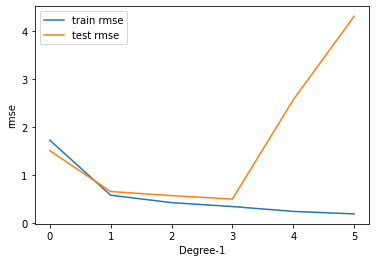

In [58]:
plt.plot(train_rmse_list, label='train rmse')
plt.plot(test_rmse_list, label='test rmse')
plt.xlabel('Degree-1')
plt.ylabel('rmse')
plt.legend()
plt.show()

In [59]:
#d=4
pf4 = PolynomialFeatures(degree=4, include_bias=False)
X_train_poly4 = pf4.fit_transform(X_train)  #w1, w2, w3... 
X_test_poly4 = pf4.transform(X_test)


poly4_model = LinearRegression().fit(X_train_poly4, y_train)
y_pred_poly4_train = poly4_model.predict(X_train_poly4)
y_pred_poly4_test = poly4_model.predict(X_test_poly4)


poly4_mse_train = mean_squared_error(y_train, y_pred_poly4_train)
poly4_rmse_train = np.sqrt(poly4_mse_train)
poly4_mse_test = mean_squared_error(y_test, y_pred_poly4_test)
poly4_rmse_test = np.sqrt(poly4_mse_test)

In [60]:
print(poly4_rmse_train)
print(poly4_rmse_test)

0.35170836883993567
0.5077742639780601


In [ ]:
#transform

#tv, radio, newspaper --> linear reg: y = w1*tv + w2*radio + w3*np
#tv^2 , radio^2,  --> poly reg : y = w1*tv^2 + w2*radio^2 + ... + w3*(radio*tv) + w4*(np*tv) + ... 
#tv, radio, newspaper, ...